In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [11]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print(f"\nРазмерность данных: {X.shape}")
print(f"Количество признаков: {X.shape[1]}")
print(f"Количество наблюдений: {X.shape[0]}")
print(f"\nКлассы: {data.target_names}")
print(f"Распределение классов:\n{y.value_counts()}")
print(f"Доля класса 1 (malignant): {y.value_counts()[1] / len(y):.2%}")
print(f"Доля класса 0 (benign): {y.value_counts()[0] / len(y):.2%}")

print(X.head())

print("\nСтатистическое описание признаков:")
print(X.describe())


Размерность данных: (569, 30)
Количество признаков: 30
Количество наблюдений: 569

Классы: ['malignant' 'benign']
Распределение классов:
target
1    357
0    212
Name: count, dtype: int64
Доля класса 1 (malignant): 62.74%
Доля класса 0 (benign): 37.26%
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790        

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nДанные нормализованы с помощью StandardScaler")
print("Среднее значение признаков после нормализации (должно быть ~0):")
print(f"{X_train_scaled.mean():.6f}")
print("Стандартное отклонение после нормализации (должно быть ~1):")
print(f"{X_train_scaled.std():.6f}")


Размер обучающей выборки: (455, 30)
Размер тестовой выборки: (114, 30)

Данные нормализованы с помощью StandardScaler
Среднее значение признаков после нормализации (должно быть ~0):
-0.000000
Стандартное отклонение после нормализации (должно быть ~1):
1.000000


In [19]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=10000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

base_results = {}

for name, model in models.items():
    print(f"\nОбучение модели: {name}")

    if name in ['Logistic Regression', 'SVM', 'K-Nearest Neighbors']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    base_results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred_proba': y_pred_proba
    }

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")

results_df = pd.DataFrame(base_results).T
print("\n", results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']])


Обучение модели: Logistic Regression
  Accuracy: 0.9825
  Precision: 0.9861
  Recall: 0.9861
  F1-Score: 0.9861
  ROC-AUC: 0.9954

Обучение модели: Decision Tree
  Accuracy: 0.9123
  Precision: 0.9559
  Recall: 0.9028
  F1-Score: 0.9286
  ROC-AUC: 0.9157

Обучение модели: Random Forest
  Accuracy: 0.9561
  Precision: 0.9589
  Recall: 0.9722
  F1-Score: 0.9655
  ROC-AUC: 0.9937

Обучение модели: Gradient Boosting
  Accuracy: 0.9561
  Precision: 0.9467
  Recall: 0.9861
  F1-Score: 0.9660
  ROC-AUC: 0.9907

Обучение модели: SVM
  Accuracy: 0.9825
  Precision: 0.9861
  Recall: 0.9861
  F1-Score: 0.9861
  ROC-AUC: 0.9950

Обучение модели: K-Nearest Neighbors
  Accuracy: 0.9561
  Precision: 0.9589
  Recall: 0.9722
  F1-Score: 0.9655
  ROC-AUC: 0.9788

                      accuracy precision    recall        f1   roc_auc
Logistic Regression  0.982456  0.986111  0.986111  0.986111   0.99537
Decision Tree        0.912281  0.955882  0.902778  0.928571  0.915675
Random Forest         0.95614  0

In [15]:
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto', 0.001, 0.01]
    }
}

tuned_results = {}
best_models = {}

for name in ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM']:
    print(f"\nНастройка гиперпараметров для: {name}")
    print(f"Количество комбинаций для проверки: ", end="")

    if name == 'Logistic Regression':
        base_model = LogisticRegression(random_state=42, max_iter=10000)
        X_train_use = X_train_scaled
        X_test_use = X_test_scaled
    elif name == 'Decision Tree':
        base_model = DecisionTreeClassifier(random_state=42)
        X_train_use = X_train
        X_test_use = X_test
    elif name == 'Random Forest':
        base_model = RandomForestClassifier(random_state=42)
        X_train_use = X_train
        X_test_use = X_test
    else:  # SVM
        base_model = SVC(probability=True, random_state=42)
        X_train_use = X_train_scaled
        X_test_use = X_test_scaled

    n_combinations = np.prod([len(v) for v in param_grids[name].values()])
    print(n_combinations)

    grid_search = GridSearchCV(
        base_model,
        param_grids[name],
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train_use, y_train)

    best_model = grid_search.best_estimator_
    best_models[name] = best_model

    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучший ROC-AUC на кросс-валидации: {grid_search.best_score_:.4f}")

    y_pred = best_model.predict(X_test_use)
    y_pred_proba = best_model.predict_proba(X_test_use)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    tuned_results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred_proba': y_pred_proba,
        'best_params': grid_search.best_params_
    }

    print(f"Результаты на тестовой выборке:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")


Настройка гиперпараметров для: Logistic Regression
Количество комбинаций для проверки: 10
Лучшие параметры: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Лучший ROC-AUC на кросс-валидации: 0.9941
Результаты на тестовой выборке:
  Accuracy: 0.9825
  Precision: 0.9861
  Recall: 0.9861
  F1-Score: 0.9861
  ROC-AUC: 0.9960

Настройка гиперпараметров для: Decision Tree
Количество комбинаций для проверки: 90
Лучшие параметры: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Лучший ROC-AUC на кросс-валидации: 0.9615
Результаты на тестовой выборке:
  Accuracy: 0.9123
  Precision: 0.9559
  Recall: 0.9028
  F1-Score: 0.9286
  ROC-AUC: 0.9656

Настройка гиперпараметров для: Random Forest
Количество комбинаций для проверки: 108
Лучшие параметры: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Лучший ROC-AUC на кросс-валидации: 0.9894
Результаты на тестовой выборке:
  Accuracy: 0.9561
  Precision: 0.9589
  Recall: 0.

In [16]:

tuned_results_df = pd.DataFrame(tuned_results).T
print("\nРезультаты после настройки гиперпараметров:")
print(tuned_results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']])

comparison_data = []
for name in tuned_results.keys():
    comparison_data.append({
        'Модель': name,
        'ROC-AUC (базовая)': base_results[name]['roc_auc'],
        'ROC-AUC (настроенная)': tuned_results[name]['roc_auc'],
        'Улучшение': tuned_results[name]['roc_auc'] - base_results[name]['roc_auc']
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nСравнение ROC-AUC до и после настройки:")
print(comparison_df)


Результаты после настройки гиперпараметров:
                     accuracy precision    recall        f1   roc_auc
Logistic Regression  0.982456  0.986111  0.986111  0.986111  0.996032
Decision Tree        0.912281  0.955882  0.902778  0.928571  0.965608
Random Forest         0.95614  0.958904  0.972222  0.965517  0.993056
SVM                  0.982456  0.986111  0.986111  0.986111  0.997685

Сравнение ROC-AUC до и после настройки:
                Модель  ROC-AUC (базовая)  ROC-AUC (настроенная)  Улучшение
0  Logistic Regression           0.995370               0.996032   0.000661
1        Decision Tree           0.915675               0.965608   0.049934
2        Random Forest           0.993717               0.993056  -0.000661
3                  SVM           0.995040               0.997685   0.002646



ПОСТРОЕНИЕ ROC-КРИВЫХ


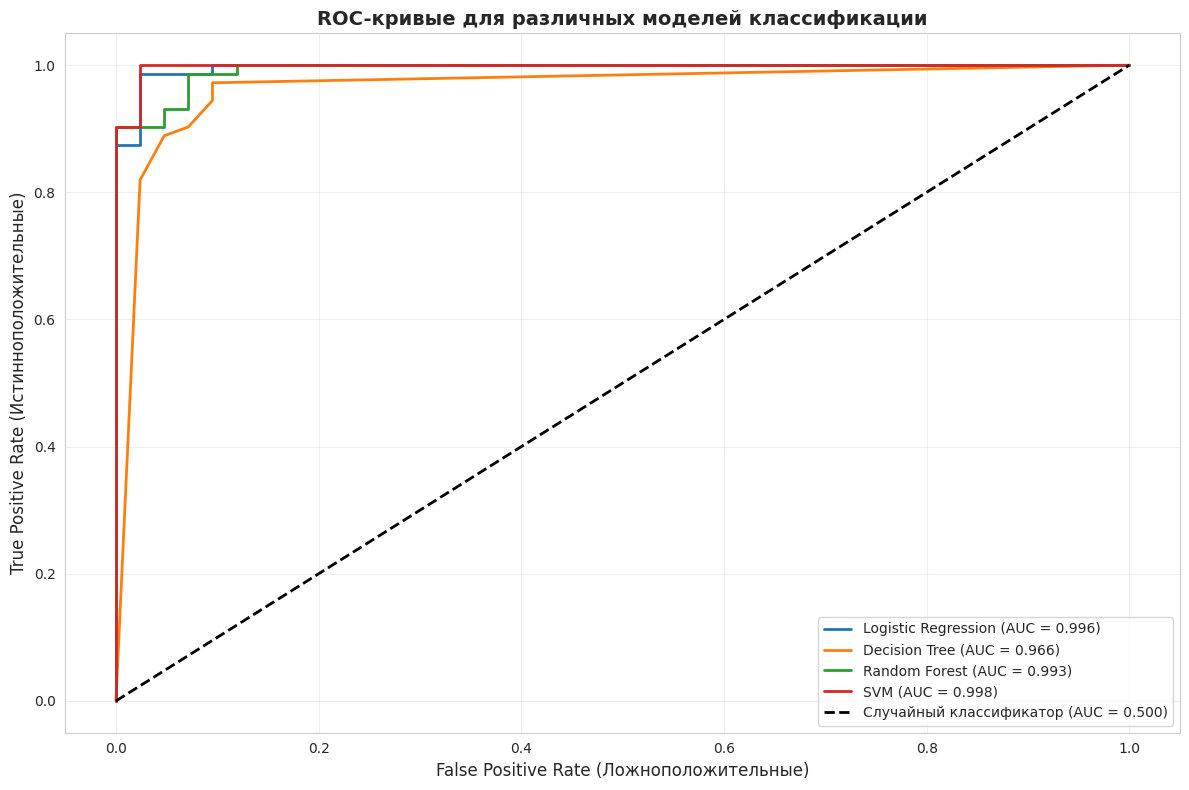


ROC-кривые построены успешно
ROC-AUC показывает способность модели различать классы
Чем ближе кривая к верхнему левому углу, тем лучше модель


In [7]:

plt.figure(figsize=(12, 8))

for name, results in tuned_results.items():
    fpr, tpr, _ = roc_curve(y_test, results['y_pred_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results['roc_auc']:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор (AUC = 0.500)', linewidth=2)

plt.xlabel('False Positive Rate (Ложноположительные)', fontsize=12)
plt.ylabel('True Positive Rate (Истинноположительные)', fontsize=12)
plt.title('ROC-кривые для различных моделей классификации', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("ROC-AUC показывает способность модели различать классы")
print("Чем ближе кривая к верхнему левому углу, тем лучше модель")


ВЫБОР ЛУЧШЕЙ МОДЕЛИ

Лучшая модель: SVM
ROC-AUC: 0.9977
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1-Score: 0.9861

Лучшие параметры: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Детальный отчет классификации:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



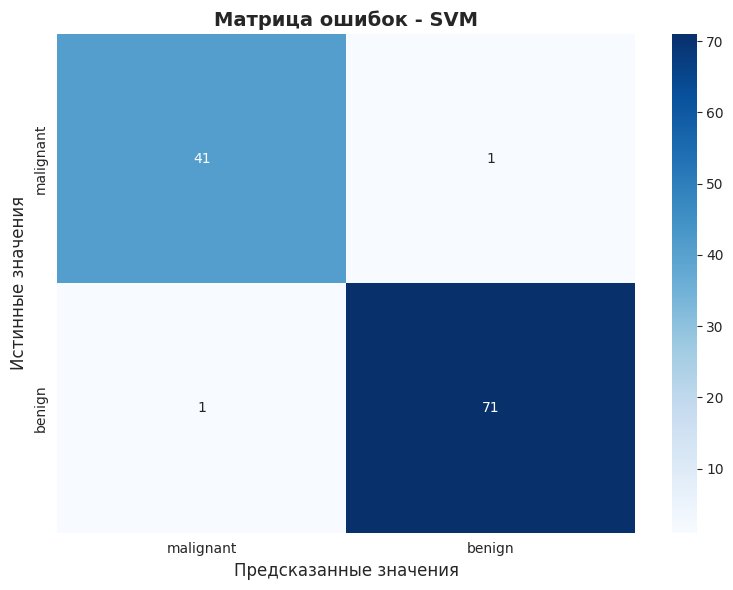


Матрица ошибок показывает:
True Negatives (верно предсказан класс 0): 41
False Positives (ошибочно предсказан класс 1): 1
False Negatives (ошибочно предсказан класс 0): 1
True Positives (верно предсказан класс 1): 71


In [8]:
best_model_name = max(tuned_results.keys(), key=lambda x: tuned_results[x]['roc_auc'])
best_model_results = tuned_results[best_model_name]

print(f"\nЛучшая модель: {best_model_name}")
print(f"ROC-AUC: {best_model_results['roc_auc']:.4f}")
print(f"Accuracy: {best_model_results['accuracy']:.4f}")
print(f"Precision: {best_model_results['precision']:.4f}")
print(f"Recall: {best_model_results['recall']:.4f}")
print(f"F1-Score: {best_model_results['f1']:.4f}")
print(f"\nЛучшие параметры: {best_model_results['best_params']}")

if best_model_name in ['Logistic Regression', 'SVM']:
    y_pred_best = best_models[best_model_name].predict(X_test_scaled)
else:
    y_pred_best = best_models[best_model_name].predict(X_test)

print("\nДетальный отчет классификации:")
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.title(f'Матрица ошибок - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Истинные значения', fontsize=12)
plt.xlabel('Предсказанные значения', fontsize=12)
plt.tight_layout()
plt.show()

print("\nМатрица ошибок показывает:")
print(f"True Negatives (верно предсказан класс 0): {cm[0, 0]}")
print(f"False Positives (ошибочно предсказан класс 1): {cm[0, 1]}")
print(f"False Negatives (ошибочно предсказан класс 0): {cm[1, 0]}")
print(f"True Positives (верно предсказан класс 1): {cm[1, 1]}")

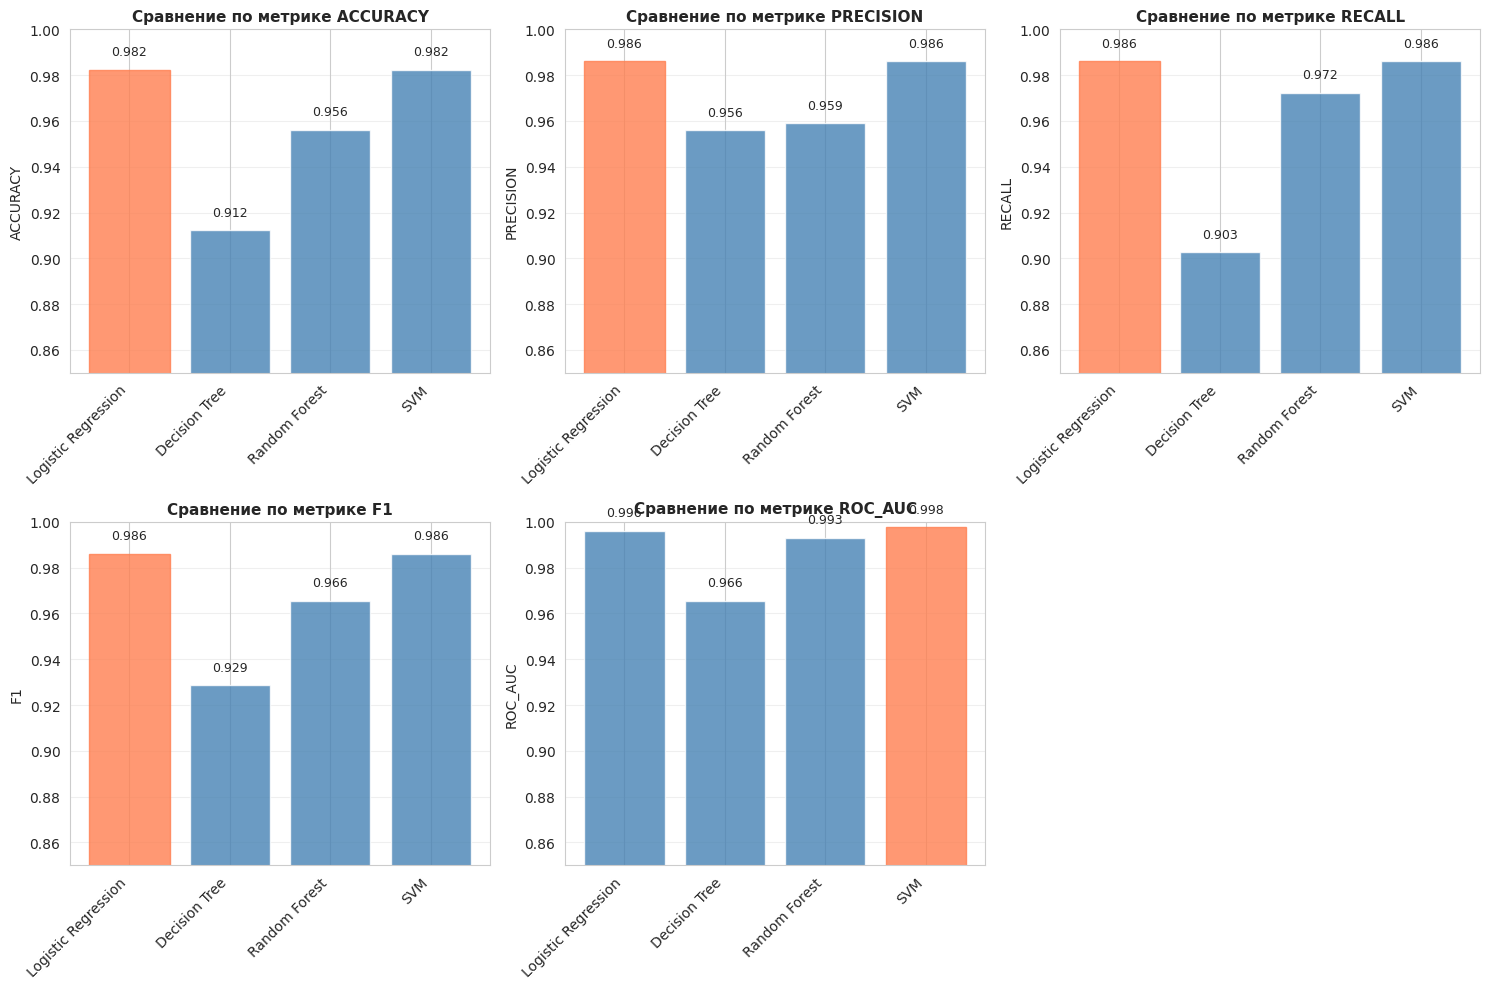

Оранжевым цветом выделены лучшие результаты по каждой метрике


In [17]:

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    model_names = list(tuned_results.keys())
    values = [tuned_results[name][metric] for name in model_names]

    bars = ax.bar(range(len(model_names)), values, color='steelblue', alpha=0.8)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=45, ha='right')
    ax.set_ylabel(metric.upper(), fontsize=10)
    ax.set_title(f'Сравнение по метрике {metric.upper()}', fontsize=11, fontweight='bold')
    ax.set_ylim([0.85, 1.0])
    ax.grid(True, alpha=0.3, axis='y')

    best_idx = values.index(max(values))
    bars[best_idx].set_color('coral')

    for i, v in enumerate(values):
        ax.text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

print("Оранжевым цветом выделены лучшие результаты по каждой метрике")